# Generate a Parity-Check Matrix of a Regular LDPC Code 

This code is provided as supplementary material of the lecture Channel Coding - Graph-based Codes.

This code illustrates
* get parity-check matrix of a regular $[d_{\mathrm{v}},d_{\mathrm{c}}]$ LDPC code using the socket and permutation technique
* Visualization of the parity-check matrix

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
rng = np.random.default_rng()

Main function that generates the parity-check matrix using the socket and permutation technique

In [4]:
def getRegularH(N, dv, dc):
    """
    get parity-check matrix of a regular [dv,dc] LDPC code using the socket
    and permutation technique
    """
    # number of edges
    E = N*dv

    # number of check nodes
    M = E/dc

    if M != np.floor(M):
        assert False, "Code construction with given size not possible, as it would lead to a non-integer number of check nodes"
    
    # nodes connected to sockets
    idx_j = np.ceil(np.arange(1, E+1) / dc).astype(int) - 1
    idx_i = np.ceil(np.arange(1, E+1) / dv).astype(int) - 1

    # random permutation
    idx_j = rng.permutation(idx_j)

    # try to construct matrix and eliminate double edges
    abort = False

    while not abort:
        H = coo_matrix((np.ones_like(idx_i), (idx_j, idx_i)), shape=(int(M), N)).toarray()

        if not np.any(H == 2):
            abort = True
        else:
            # eliminate double edges
            for k in range(N):
                ti = np.where(idx_i == k)[0]

                unique_idx, counts = np.unique(idx_j[ti], return_counts=True)
                duplicates = unique_idx[counts > 1] # duplicates
                if duplicates.size > 0:
                    largeval = duplicates[0]
                    largeidx = np.where(idx_j[ti] == largeval)[0][0]
                    temp = idx_j[ti[largeidx]]
                    rv = rng.integers(idx_j.size)
                    idx_j[ti[largeidx]] = idx_j[rv]
                    idx_j[rv] = temp
    
    return H

Function that removes 4-cycles from a parity-check matrix. See lecture for details

In [5]:
def myrandsample(v, num):
    idx = rng.integers(v.size, size=num)
    return v[idx]

def remove_4cycle(H):
    # removes cycles of length 4
    success = True
    _, N = H.shape

    abort = False
    trials = 0
    while not abort:
        T = H.T @ H - np.diag(np.sum(H, axis=0))
        v1s, v2s = np.where(np.triu(T) >= 2)
        # vs[:,1].size
        if v1s.size == 0: # array is empty
            abort = True
        
        for k in range(v1s.size):
            v1 = v1s[k]
            v2 = v2s[k]

            # common check node
            cncs = np.where(H[:,v1] + H[:,v2] == 2)[0]
            if cncs.size >= 2:
                cn = np.where(H[:,v1] + H[:,v2] == 2)[0][0]
                find_replace = False
                
                while not find_replace:
                    vni = myrandsample(np.setdiff1d(np.arange(N), [v1, v2]), 1)[0]
                    if np.all(H[:,v2] * H[:,vni] == 0):
                        cnt = myrandsample(np.where(H[:,vni])[0], 1)[0]
                        # swap edges
                        temp = H[[cnt, cn], v2]
                        H[[cnt, cn], v2] = H[[cnt, cn], vni]
                        H[[cnt, cn], vni] = temp
                        find_replace = True
        
        trials += 1
        if trials > 500:
            success = False
            abort = True
    
    return H, success


Generate a code (in this case, a regular $[3,6]$ code of length $n=2$8) and plot the parity-check matrix

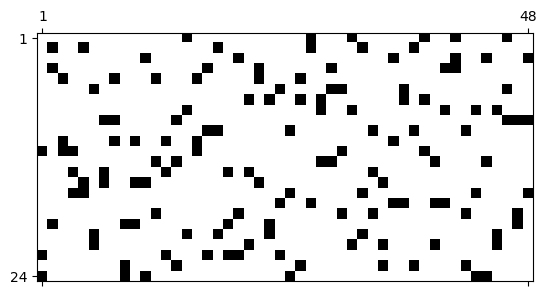

In [6]:
H = getRegularH(48, 3, 6)
plt.spy(H)
m, n = H.shape

plt.xticks([0, n-1], [1, n])
plt.yticks([0, m-1], [1, m])
plt.show()

Try to remove 4-cycles using a very simple algorithm. Show the matrix if available, otherwise give an error message.

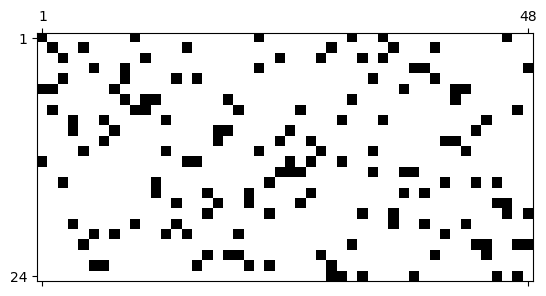

In [7]:
H_no4, success = remove_4cycle(H)
if success:
    plt.spy(H_no4)
    m, n = H_no4.shape

    plt.xticks([0, n-1], [1, n])
    plt.yticks([0, m-1], [1, m])
    plt.show()
else:   
    print("Could not remove all 4-cycles after 500 trials")